In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

here = Path.cwd()
candidates = [here, here.parent, here.parent.parent]
PROCESSED = next((c / "data" / "processed" for c in candidates if (c / "data" / "processed").exists()), None)
FIGURES = PROCESSED.parent.parent / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED / "ethiopia_fi_unified_data_enriched.csv")
df["observation_date"] = pd.to_datetime(df["observation_date"], errors="coerce")

obs = df[df["record_type"] == "observation"].copy()
events = df[df["record_type"] == "event"].copy()
links = df[df["record_type"] == "impact_link"].copy()

sns.set_theme(style="whitegrid")
print(df["record_type"].value_counts())

record_type
observation    32
impact_link    11
event          10
target          3
Name: count, dtype: int64


record_type  pillar       
impact_link  ACCESS            5
             AFFORDABILITY     1
             GENDER            1
             USAGE             4
observation  ACCESS           16
             AFFORDABILITY     1
             GENDER            4
             USAGE            11
target       ACCESS            2
             GENDER            1
dtype: int64


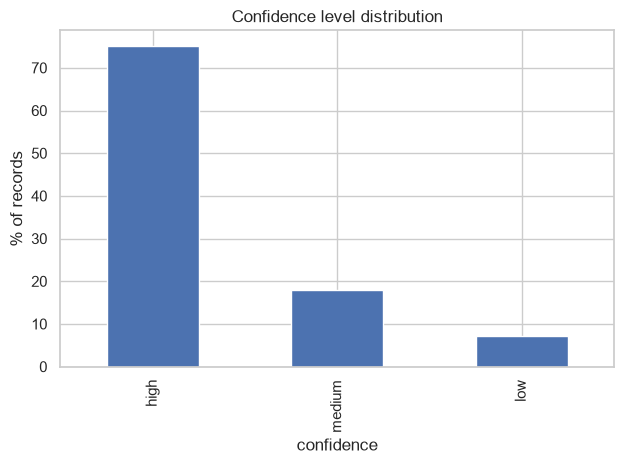

In [2]:
print(df.groupby(["record_type", "pillar"]).size())

conf_dist = df["confidence"].value_counts(normalize=True) * 100
conf_dist.plot(kind="bar", title="Confidence level distribution")
plt.ylabel("% of records")
plt.tight_layout(); plt.savefig(FIGURES / "confidence_distribution.png"); plt.show()

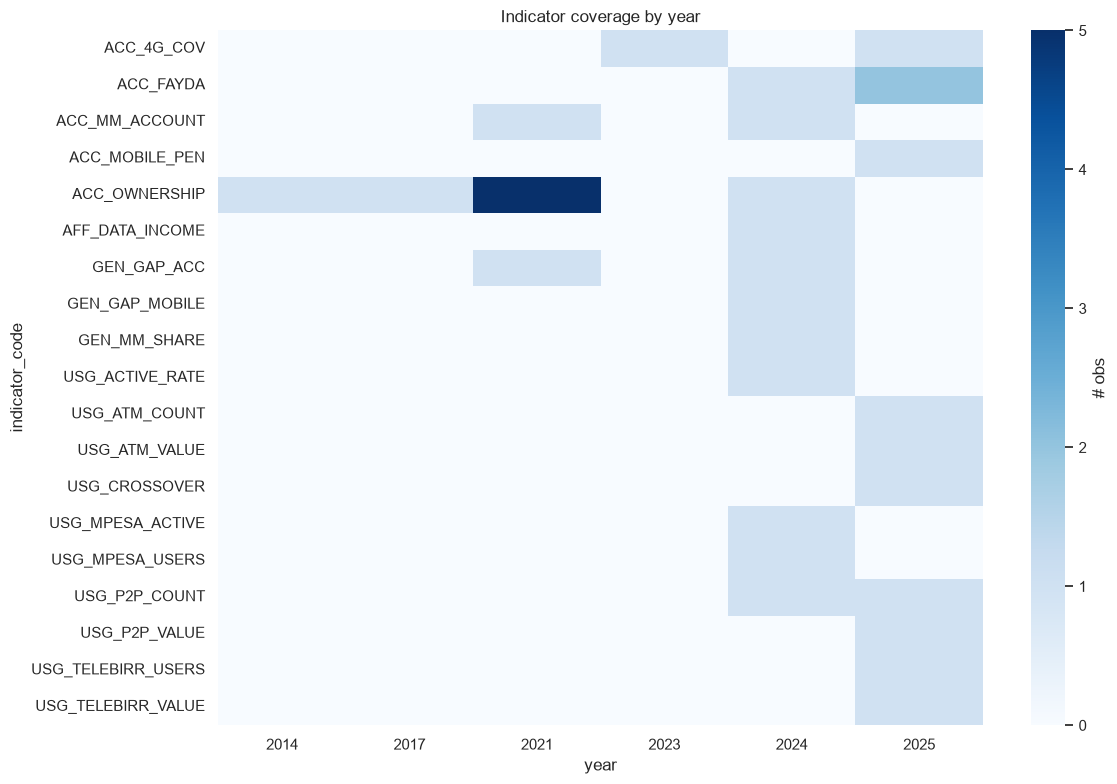

In [3]:
coverage = (obs.assign(year=obs["observation_date"].dt.year)
              .pivot_table(index="indicator_code", columns="year",
                           values="value_numeric", aggfunc="count", fill_value=0))
plt.figure(figsize=(12, 8))
sns.heatmap(coverage, cmap="Blues", cbar_kws={"label": "# obs"})
plt.title("Indicator coverage by year")
plt.tight_layout(); plt.savefig(FIGURES / "coverage_heatmap.png"); plt.show()

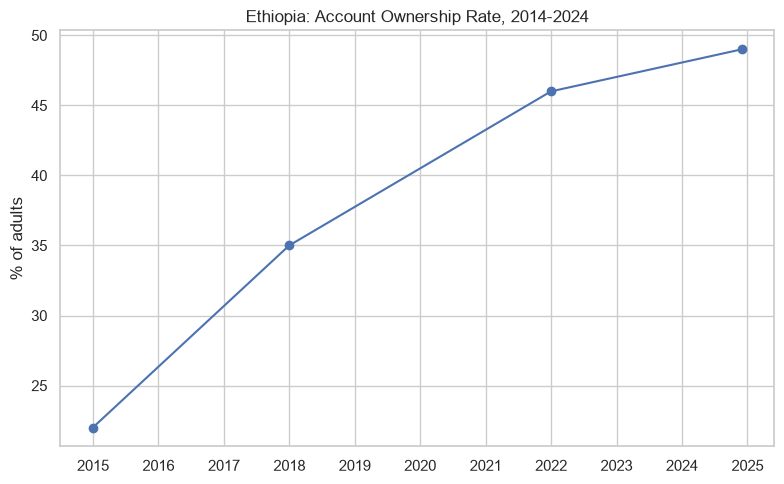

  observation_date  value_numeric  growth_pp  pp_per_year
0       2014-12-31           22.0        NaN          NaN
1       2017-12-31           35.0       13.0     4.333333
2       2021-12-31           46.0       11.0     2.750000
5       2024-11-29           49.0        3.0     1.000000


In [4]:
acc = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["gender"] == "all")
          & (obs["location"] == "national")].sort_values("observation_date")

plt.figure(figsize=(8, 5))
plt.plot(acc["observation_date"], acc["value_numeric"], marker="o")
plt.title("Ethiopia: Account Ownership Rate, 2014-2024")
plt.ylabel("% of adults")
plt.tight_layout(); plt.savefig(FIGURES / "access_trajectory.png"); plt.show()

acc["growth_pp"] = acc["value_numeric"].diff()
acc["years_elapsed"] = acc["observation_date"].dt.year.diff()
acc["pp_per_year"] = acc["growth_pp"] / acc["years_elapsed"]
print(acc[["observation_date", "value_numeric", "growth_pp", "pp_per_year"]])

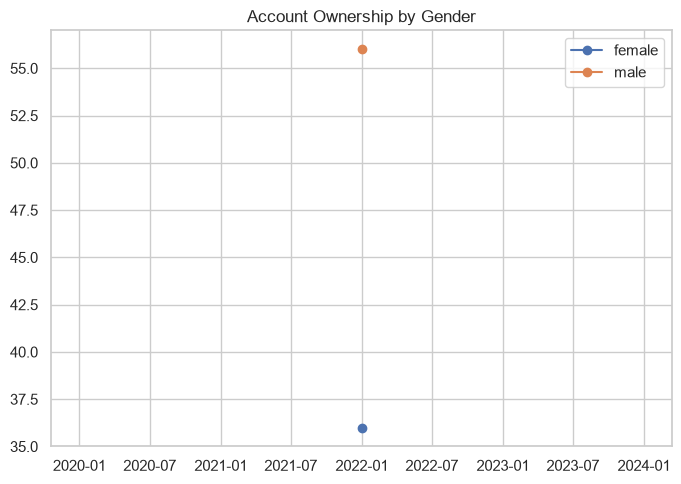

   observation_date  value_numeric notes
26       2021-12-31           20.0   NaN
27       2024-11-29           18.0   NaN


In [5]:
gender = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["gender"].isin(["male", "female"]))]
gender = gender.sort_values("observation_date")

plt.figure(figsize=(7, 5))
for g, grp in gender.groupby("gender"):
    plt.plot(grp["observation_date"], grp["value_numeric"], marker="o", label=g)
plt.legend(); plt.title("Account Ownership by Gender")
plt.tight_layout(); plt.savefig(FIGURES / "gender_gap.png"); plt.show()

gap = obs[obs["indicator_code"] == "GEN_GAP_ACC"].sort_values("observation_date")
print(gap[["observation_date", "value_numeric", "notes"]])

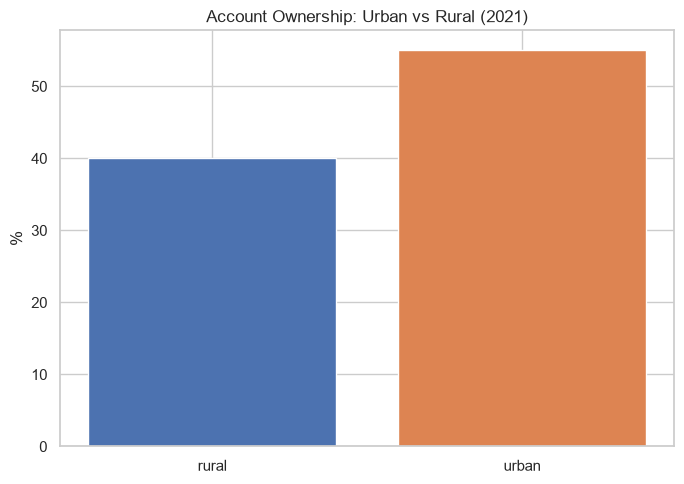

In [6]:
ur = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["location"].isin(["urban", "rural"]))]
plt.figure(figsize=(7, 5))
for loc, grp in ur.groupby("location"):
    plt.bar(loc, grp["value_numeric"].values[0])
plt.title("Account Ownership: Urban vs Rural (2021)")
plt.ylabel("%")
plt.tight_layout(); plt.savefig(FIGURES / "urban_rural.png"); plt.show()

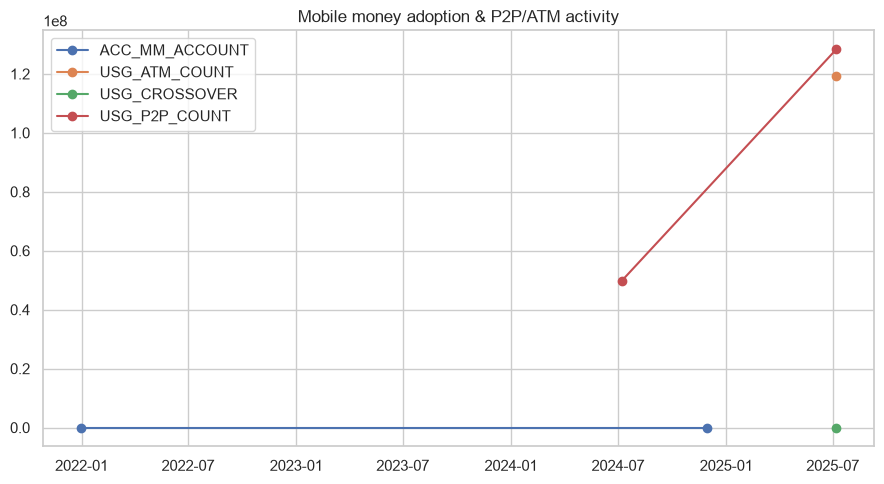

In [7]:
usage_codes = ["ACC_MM_ACCOUNT", "USG_P2P_COUNT", "USG_ATM_COUNT", "USG_CROSSOVER"]
usage = obs[obs["indicator_code"].isin(usage_codes)].sort_values("observation_date")

fig, ax = plt.subplots(figsize=(9, 5))
for code, grp in usage.groupby("indicator_code"):
    ax.plot(grp["observation_date"], grp["value_numeric"], marker="o", label=code)
ax.legend(); ax.set_title("Mobile money adoption & P2P/ATM activity")
plt.tight_layout(); plt.savefig(FIGURES / "usage_trend.png"); plt.show()

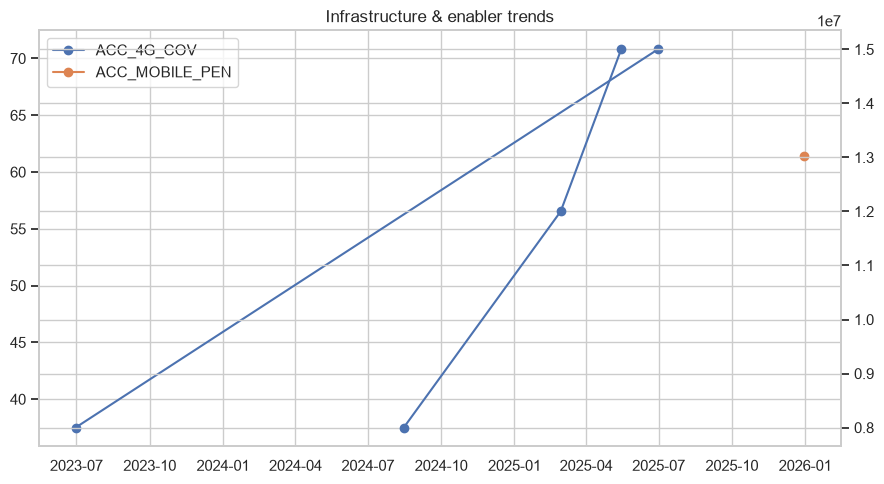

In [8]:
infra_codes = ["ACC_4G_COV", "ACC_MOBILE_PEN", "ACC_FAYDA"]
infra = obs[obs["indicator_code"].isin(infra_codes)].sort_values("observation_date")

fig, ax = plt.subplots(figsize=(9, 5))
for code, grp in infra.groupby("indicator_code"):
    ax2 = ax.twinx() if code == "ACC_FAYDA" else ax  # Fayda is in raw counts, others %
    ax2.plot(grp["observation_date"], grp["value_numeric"], marker="o", label=code)
ax.legend(loc="upper left"); ax.set_title("Infrastructure & enabler trends")
plt.tight_layout(); plt.savefig(FIGURES / "infrastructure_trends.png"); plt.show()

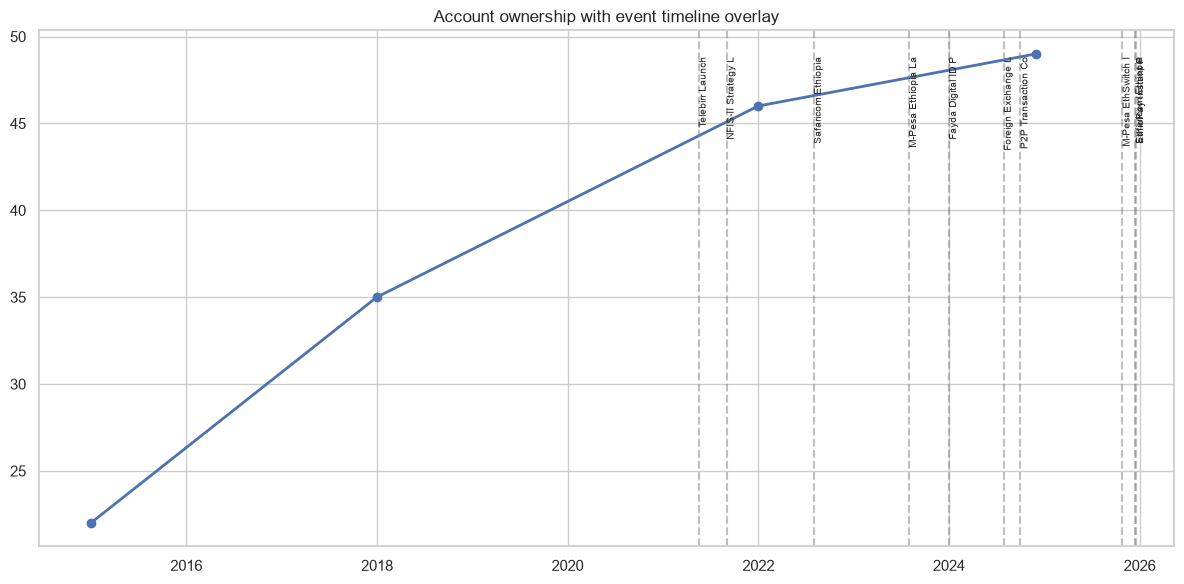

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(acc["observation_date"], acc["value_numeric"], marker="o", linewidth=2, label="Account ownership")
for _, ev in events.iterrows():
    ax.axvline(ev["observation_date"], color="gray", linestyle="--", alpha=0.5)
    ax.text(ev["observation_date"], ax.get_ylim()[1]*0.97, ev["indicator"][:18],
            rotation=90, fontsize=7, va="top")
ax.set_title("Account ownership with event timeline overlay")
plt.tight_layout(); plt.savefig(FIGURES / "events_overlay.png"); plt.show()

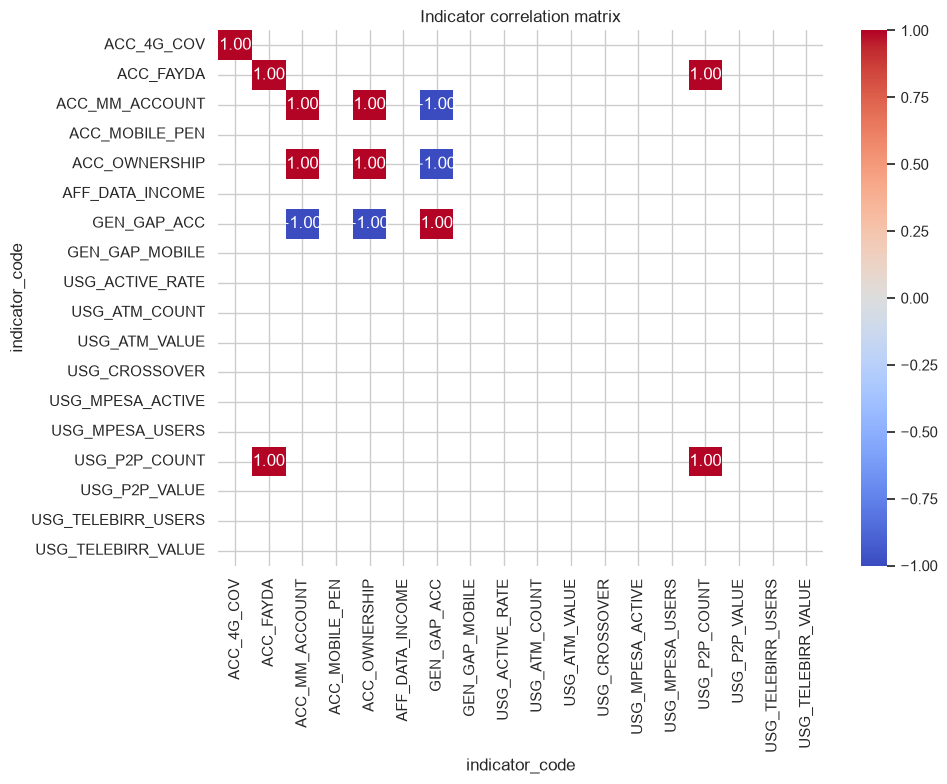

In [10]:
pivot = obs[obs["gender"]=="all"].pivot_table(
    index=obs["observation_date"].dt.year, columns="indicator_code", values="value_numeric")
corr = pivot.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Indicator correlation matrix")
plt.tight_layout(); plt.savefig(FIGURES / "correlation_matrix.png"); plt.show()

In [11]:
links_view = links.merge(events[["record_id", "indicator"]], left_on="parent_id",
                          right_on="record_id", suffixes=("", "_event"))
links_view[["indicator_event", "related_indicator", "relationship_type",
            "impact_direction", "impact_magnitude", "confidence"]]

,indicator_event,related_indicator,relationship_type,impact_direction,impact_magnitude,confidence
0,Telebirr Launch,ACC_OWNERSHIP,indirect,increase,medium,medium
1,NFIS-II Strategy Launch,ACC_OWNERSHIP,enabling,increase,medium,medium
2,NFIS-II Strategy Launch,ACC_FAYDA,enabling,increase,medium,low
3,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,enabling,increase,medium,low
4,Fayda Digital ID Program Rollout,GEN_GAP_ACC,indirect,decrease,low,low
5,Foreign Exchange Liberalization,AFF_DATA_INCOME,indirect,increase,medium,low
6,Foreign Exchange Liberalization,USG_TELEBIRR_VALUE,indirect,increase,medium,medium
7,P2P Transaction Count Surpasses ATM,USG_ATM_COUNT,constraining,stabilize,low,medium
8,M-Pesa EthSwitch Integration,USG_MPESA_ACTIVE,direct,increase,medium,medium
9,EthioPay Instant Payment System Launch,USG_CROSSOVER,direct,increase,high,medium


## Key Insights

1. Account ownership growth decelerated from +11pp (2017-21) to +3pp (2021-24) despite
   Telebirr surpassing 54M registered users — a registered-vs-active usage gap.
2. Mobile-money-only account ownership stayed at 9.45% in 2024, consistent with most
   mobile money users already holding bank accounts.
3. The gender gap in account ownership narrowed from 20pp (2021) to an estimated 18pp
   (2024), but women hold only 14% of mobile money accounts specifically.
4. P2P transaction count surpassed ATM withdrawals for the first time in Oct 2024
   (crossover ratio 1.08), signaling a structural shift to digital payments.
5. [Fill in from your correlation matrix — which indicators move together most strongly?]

## Data Quality Assessment
- Only 5 Findex survey points span 2011-2024 for account ownership — most other
  indicators have 1-3 observations, sparse for time series modeling.
- No 2025/2026 Findex round exists yet, so 2025-27 forecasting requires extrapolation.
- Most confidence ratings are "high" (primary sources), but impact_link confidence
  is mostly medium/low since events are recent and pre/post effects aren't yet measurable.